# Bài 2: Vẽ Waveform và Phổ tần số (FFT)

**Mục tiêu:**
- Vẽ dạng sóng (waveform) bằng matplotlib
- Tính và vẽ phổ biên độ bằng FFT (`numpy.fft`)  
**Gợi ý:** Chỉ dùng `matplotlib` và **không set màu thủ công**.

In [ ]:
#@title Cài đặt (nếu cần)
# !pip install scipy matplotlib


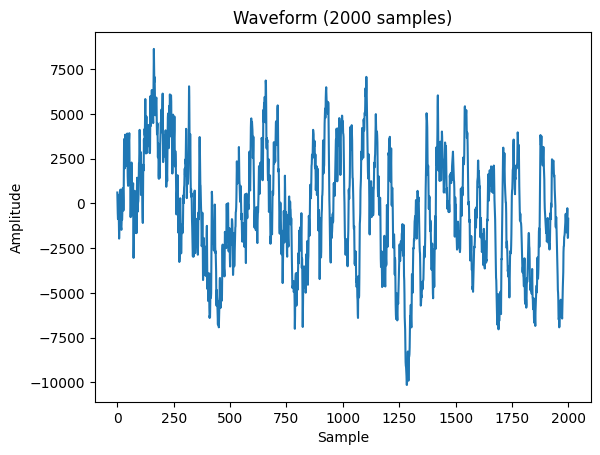

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

filename = "sample-6s.wav"  # Thay bằng tệp của bạn
rate, data = wavfile.read(filename)

# Nếu stereo -> lấy 1 kênh
if data.ndim == 2:
    data = data[:,0]

# Vẽ waveform (một phần để dễ nhìn)
N_show = min(len(data), 2000)
plt.figure()
plt.plot(np.arange(N_show), data[:N_show])
plt.title("Waveform ({} samples)".format(N_show))
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

### Phân tích phổ tần số bằng FFT

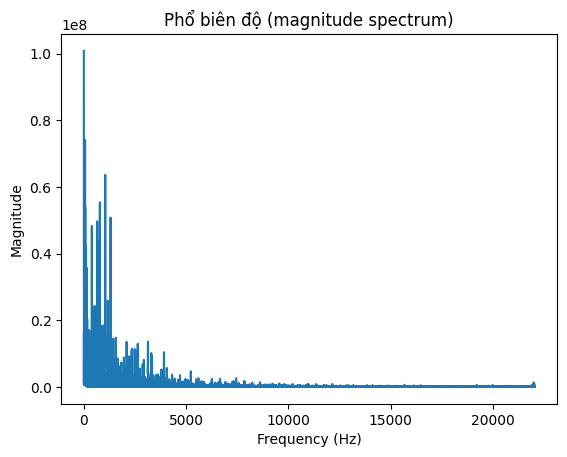

In [3]:
# Tính FFT và trục tần số
N = len(data)
yf = np.fft.fft(data)
xf = np.fft.fftfreq(N, 1.0 / rate)

# Chỉ lấy nửa dương
half = N // 2
plt.figure()
plt.plot(xf[:half], np.abs(yf[:half]))
plt.title("Phổ biên độ (magnitude spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()